# 08 - Final Model Comparison and Risk Maps

This notebook compares available model prediction files, creates risk maps, summarizes monthly behavior, and writes a final report. It does not train models. Run it after notebook `06` and, if possible, notebook `07`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Edit this path to the location where you uploaded the project folder in Google Drive.
PROJECT_DIR = "/content/drive/MyDrive/fire-risk-project"
PROJECT_DIR = Path(PROJECT_DIR)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for path in [FIGURES_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

GRID_PATH = PROCESSED_DIR / "morocco_ws_grid.geojson"
FULL_RF_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023.csv"
FILTERED_RF_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_filtered_rf.csv"
TEMPORAL_CNN_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_temporal_cnn.csv"
LSTM_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_lstm.csv"
FILTERED_THRESHOLD_METRICS_PATH = REPORTS_DIR / "threshold_metrics_random_forest_2023_filtered.csv"
TEMPORAL_METRICS_PATH = REPORTS_DIR / "temporal_model_metrics_2023.csv"

MODEL_COMPARISON_PATH = REPORTS_DIR / "model_comparison_2023.csv"
MONTHLY_SUMMARY_PATH = REPORTS_DIR / "monthly_prediction_summary_2023.csv"
FINAL_REPORT_PATH = REPORTS_DIR / "final_report_2023.md"
MODEL_PR_CURVES_PATH = FIGURES_DIR / "model_precision_recall_comparison_2023.png"
RISK_MAP_PATH = FIGURES_DIR / "selected_model_risk_probability_map.png"
ALERT_MAP_PATH = FIGURES_DIR / "selected_model_alert_map.png"


Mounted at /content/drive


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
)


## Load Available Prediction Files

This notebook is robust to missing prediction files. It compares whatever has already been generated.


In [3]:
prediction_specs = [
    {"model": "rf_full", "path": FULL_RF_PREDICTIONS_PATH, "label_col": "fire_risk_label", "prob_col": "pred_probability", "pred_col": "pred_label"},
    {"model": "rf_filtered", "path": FILTERED_RF_PREDICTIONS_PATH, "label_col": "fire_risk_label", "prob_col": "pred_probability", "pred_col": "pred_label_050"},
    {"model": "temporal_cnn", "path": TEMPORAL_CNN_PREDICTIONS_PATH, "label_col": "fire_risk_label", "prob_col": "pred_probability", "pred_col": "pred_label"},
    {"model": "lstm", "path": LSTM_PREDICTIONS_PATH, "label_col": "fire_risk_label", "prob_col": "pred_probability", "pred_col": "pred_label"},
]

predictions = {}
for spec in prediction_specs:
    if spec["path"].exists():
        pred = pd.read_csv(spec["path"])
        pred["date"] = pd.to_datetime(pred["date"])
        pred["grid_id"] = pred["grid_id"].astype(int)
        predictions[spec["model"]] = {"spec": spec, "df": pred}
        print(f"Loaded {spec['model']}: {pred.shape} from {spec['path']}")
    else:
        print(f"Missing {spec['model']}: {spec['path']}")

if not predictions:
    raise FileNotFoundError("No prediction files found. Run notebook 04, 06, or 07 first.")


Loaded rf_full: (237490, 7) from /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023.csv
Loaded rf_filtered: (236895, 7) from /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023_filtered_rf.csv
Loaded temporal_cnn: (236895, 6) from /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023_temporal_cnn.csv
Missing lstm: /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023_lstm.csv


## Compare Models

For each available model, this computes thresholded classification metrics plus ROC AUC and PR AUC from probabilities.


In [4]:
def get_default_threshold(model_name, pred_df):
    if "threshold" in pred_df.columns and pred_df["threshold"].notna().any():
        return float(pred_df["threshold"].dropna().iloc[0])
    if model_name == "rf_filtered" and FILTERED_THRESHOLD_METRICS_PATH.exists():
        threshold_metrics = pd.read_csv(FILTERED_THRESHOLD_METRICS_PATH)
        if not threshold_metrics.empty:
            return float(threshold_metrics.loc[threshold_metrics["f1"].idxmax(), "threshold"])
    return 0.5


def evaluate_predictions(model_name, pred_df, label_col="fire_risk_label", prob_col="pred_probability", threshold=0.5):
    valid = pred_df.dropna(subset=[label_col, prob_col]).copy()
    y_true = valid[label_col].astype(int).to_numpy()
    y_score = valid[prob_col].astype(float).to_numpy()
    y_pred = (y_score >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1],
        average="binary",
        zero_division=0,
    )
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "model": model_name,
        "threshold": threshold,
        "rows": len(valid),
        "positive_rate": float(np.mean(y_true)),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc": average_precision_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "alerts": int(tp + fp),
    }


rows = []
for model_name, item in predictions.items():
    spec = item["spec"]
    pred_df = item["df"]
    threshold = get_default_threshold(model_name, pred_df)
    rows.append(
        evaluate_predictions(
            model_name=model_name,
            pred_df=pred_df,
            label_col=spec["label_col"],
            prob_col=spec["prob_col"],
            threshold=threshold,
        )
    )

model_comparison = pd.DataFrame(rows).sort_values(["pr_auc", "f1"], ascending=False)
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
print("Saved:", MODEL_COMPARISON_PATH)
display(model_comparison)


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/model_comparison_2023.csv


,model,threshold,rows,positive_rate,precision,recall,f1,roc_auc,pr_auc,tp,fp,tn,fn,alerts
2,temporal_cnn,0.969612,236895,0.010308,0.424513,0.330467,0.371633,0.906304,0.331286,807,1094,233359,1635,1901
0,rf_full,0.500000,237490,0.010283,0.083991,0.688780,0.149724,0.917250,0.229791,1682,18344,216704,760,20026
1,rf_filtered,0.800000,236895,0.010308,0.277778,0.262080,0.269701,0.918522,0.213938,640,1664,232789,1802,2304


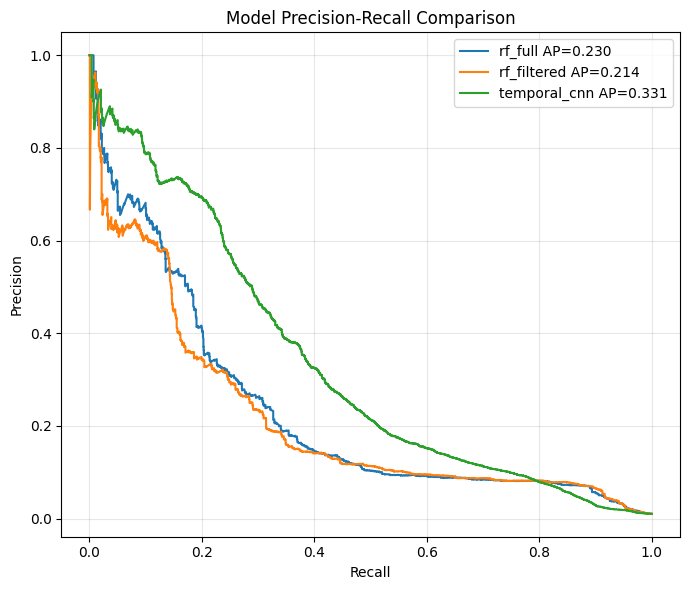

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/model_precision_recall_comparison_2023.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, item in predictions.items():
    spec = item["spec"]
    pred_df = item["df"].dropna(subset=[spec["label_col"], spec["prob_col"]])
    y_true = pred_df[spec["label_col"]].astype(int)
    y_score = pred_df[spec["prob_col"]].astype(float)
    if y_true.nunique() < 2:
        continue
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax.plot(recall, precision, label=f"{model_name} AP={ap:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Model Precision-Recall Comparison")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(MODEL_PR_CURVES_PATH, dpi=180)
plt.show()
print("Saved:", MODEL_PR_CURVES_PATH)


## Create Monthly Summary

This table helps diagnose whether a model over-warns or under-warns in specific months.


In [6]:
monthly_rows = []
for model_name, item in predictions.items():
    spec = item["spec"]
    pred_df = item["df"].copy()
    threshold = get_default_threshold(model_name, pred_df)
    pred_df["month"] = pred_df["date"].dt.month
    pred_df["alert"] = (pred_df[spec["prob_col"]] >= threshold).astype(int)
    grouped = pred_df.groupby("month").agg(
        rows=(spec["label_col"], "size"),
        positives=(spec["label_col"], "sum"),
        alerts=("alert", "sum"),
        mean_probability=(spec["prob_col"], "mean"),
        max_probability=(spec["prob_col"], "max"),
    ).reset_index()
    grouped["model"] = model_name
    grouped["threshold"] = threshold
    monthly_rows.append(grouped)

monthly_summary = pd.concat(monthly_rows, ignore_index=True)
monthly_summary.to_csv(MONTHLY_SUMMARY_PATH, index=False)
print("Saved:", MONTHLY_SUMMARY_PATH)
display(monthly_summary)


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/monthly_prediction_summary_2023.csv


,month,rows,positives,alerts,mean_probability,max_probability,model,threshold
0,10,86614,938,7562,0.114927,0.990758,rf_full,0.500000
1,11,83820,832,7056,0.100611,0.982816,rf_full,0.500000
2,12,67056,672,5408,0.098631,0.975925,rf_full,0.500000
3,10,86397,938,1083,0.114553,0.985772,rf_filtered,0.800000
4,11,83610,832,655,0.101439,0.969286,rf_filtered,0.800000
5,12,66888,672,566,0.099256,0.960040,rf_filtered,0.800000
6,10,86397,938,749,0.477469,0.999873,temporal_cnn,0.969612
7,11,83610,832,596,0.524324,0.999148,temporal_cnn,0.969612
8,12,66888,672,556,0.459263,0.999860,temporal_cnn,0.969612


## Risk Map For A Selected Model And Date

By default this selects the highest-ranked model from the comparison table and the most recent available test date. Edit `SELECTED_MODEL` and `SELECTED_DATE` if needed.


In [7]:
grid = gpd.read_file(GRID_PATH)
grid["grid_id"] = grid["grid_id"].astype(int)

SELECTED_MODEL = model_comparison.iloc[0]["model"]
selected_pred = predictions[SELECTED_MODEL]["df"].copy()
selected_spec = predictions[SELECTED_MODEL]["spec"]
SELECTED_DATE = selected_pred["date"].max()
SELECTED_THRESHOLD = float(model_comparison.iloc[0]["threshold"])

map_df = selected_pred[selected_pred["date"] == SELECTED_DATE].copy()
map_df["alert"] = (map_df[selected_spec["prob_col"]] >= SELECTED_THRESHOLD).astype(int)

risk_grid = grid.merge(
    map_df[["grid_id", selected_spec["prob_col"], "alert", selected_spec["label_col"]]],
    on="grid_id",
    how="left",
)

print("Selected model:", SELECTED_MODEL)
print("Selected date:", SELECTED_DATE)
print("Selected threshold:", SELECTED_THRESHOLD)
print("Rows mapped:", map_df.shape)


Selected model: temporal_cnn
Selected date: 2023-12-24 00:00:00
Selected threshold: 0.9696123003959656
Rows mapped: (2787, 7)


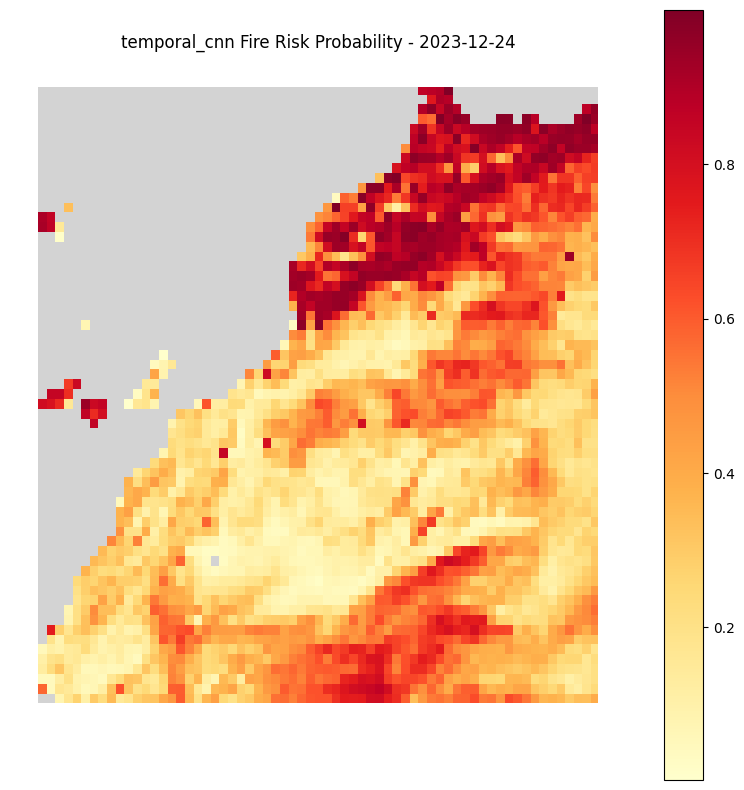

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/selected_model_risk_probability_map.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
risk_grid.plot(
    column=selected_spec["prob_col"],
    cmap="YlOrRd",
    legend=True,
    linewidth=0.03,
    edgecolor="none",
    missing_kwds={"color": "lightgrey", "label": "No prediction"},
    ax=ax,
)
ax.set_title(f"{SELECTED_MODEL} Fire Risk Probability - {SELECTED_DATE.date()}")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(RISK_MAP_PATH, dpi=180)
plt.show()
print("Saved:", RISK_MAP_PATH)


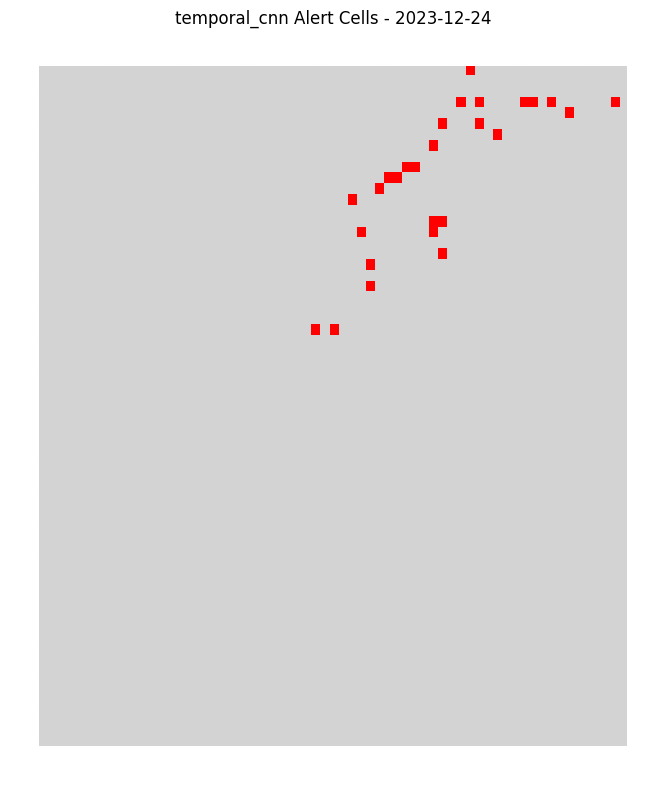

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/selected_model_alert_map.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
risk_grid.plot(color="lightgrey", linewidth=0.03, edgecolor="white", ax=ax)
risk_grid[risk_grid["alert"] == 1].plot(color="red", linewidth=0.03, edgecolor="none", ax=ax)
ax.set_title(f"{SELECTED_MODEL} Alert Cells - {SELECTED_DATE.date()}")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(ALERT_MAP_PATH, dpi=180)
plt.show()
print("Saved:", ALERT_MAP_PATH)


## Write Final Report

This report is a starting point for your final project discussion. Edit it after inspecting the maps and metrics.


In [10]:
best = model_comparison.iloc[0]

report_lines = [
    "# Fire Risk Prediction 2023 - Final Report Draft",
    "",
    "## Study Area",
    "Morocco + Western Sahara, using a regular grid over the bounding box.",
    "",
    "## Data Sources",
    "- NASA FIRMS VIIRS_SNPP_SP active fire detections",
    "- MODIS MOD13Q1.061 250m 16-day NDVI from AppEEARS",
    "- NOAA weather integration remains optional and was not required for the first baseline",
    "",
    "## Target",
    "Binary target: fire detected in the next 7 days for a grid cell.",
    "",
    "## Best Available Model In This Run",
    f"- Model: {best['model']}",
    f"- Threshold: {best['threshold']:.4f}",
    f"- Precision: {best['precision']:.4f}",
    f"- Recall: {best['recall']:.4f}",
    f"- F1: {best['f1']:.4f}",
    f"- ROC AUC: {best['roc_auc']:.4f}",
    f"- PR AUC: {best['pr_auc']:.4f}",
    f"- Alerts: {int(best['alerts'])}",
    "",
    "## Critical Interpretation",
    "High ROC AUC can coexist with low precision because fire-risk positives are rare. PR AUC, precision, recall, and alert volume should guide operational interpretation.",
    "",
    "## Main Limitations",
    "- FIRMS active fire detections are a proxy target, not confirmed burned area.",
    "- The rectangular grid includes non-burnable and sparse-vegetation areas unless filtered.",
    "- Weather, drought, land cover, elevation, and human activity features are still missing.",
    "- Results are from one year only, so temporal generalization is not proven.",
    "",
    "## Recommended Next Improvements",
    "1. Add weather or gridded climate data, preferably ERA5-Land or CHIRPS if NOAA station coverage is weak.",
    "2. Add land-cover and elevation/topography variables.",
    "3. Extend the dataset to multiple years and test on a future year.",
    "4. Evaluate Morocco and Western Sahara separately.",
    "5. Treat predictions as risk scores and choose thresholds based on the intended use case.",
    "",
    "## Generated Files",
    f"- Model comparison: {MODEL_COMPARISON_PATH}",
    f"- Monthly summary: {MONTHLY_SUMMARY_PATH}",
    f"- Risk probability map: {RISK_MAP_PATH}",
    f"- Alert map: {ALERT_MAP_PATH}",
]

FINAL_REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print("Saved:", FINAL_REPORT_PATH)
print("\n".join(report_lines[:35]))


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/final_report_2023.md
# Fire Risk Prediction 2023 - Final Report Draft

## Study Area
Morocco + Western Sahara, using a regular grid over the bounding box.

## Data Sources
- NASA FIRMS VIIRS_SNPP_SP active fire detections
- MODIS MOD13Q1.061 250m 16-day NDVI from AppEEARS
- NOAA weather integration remains optional and was not required for the first baseline

## Target
Binary target: fire detected in the next 7 days for a grid cell.

## Best Available Model In This Run
- Model: temporal_cnn
- Threshold: 0.9696
- Precision: 0.4245
- Recall: 0.3305
- F1: 0.3716
- ROC AUC: 0.9063
- PR AUC: 0.3313
- Alerts: 1901

## Critical Interpretation
High ROC AUC can coexist with low precision because fire-risk positives are rare. PR AUC, precision, recall, and alert volume should guide operational interpretation.

## Main Limitations
- FIRMS active fire detections are a proxy target, not confirmed burned area.
- The rectangular grid inc